In [28]:
# Spark Session

import setuptools
import os

from pyspark.sql import SparkSession
from pyspark.sql.functions import *

os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.19.10-hotspot" 

spark = SparkSession.builder \
    .appName("Retail Big Data") \
    .master("local[*]") \
    .config(
        "spark.jars",
        "file:///D:/proyek_bidat/bigdata_retail_anomaly/jars/postgresql-42.7.3.jar"
    ) \
    .getOrCreate()

print("SPARK BERHASIL DIJALANKAN")

SPARK BERHASIL DIJALANKAN


In [30]:
# Load Dataset CSV

df = spark.read.csv(
    "data/online_retail.csv",
    header=True,
    inferSchema=True,
    sep=";"
)

print("DATA BERHASIL DIBACA")

df.show(5)

DATA BERHASIL DIBACA
+---------+---------+--------------------+--------+-----------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+-----------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6| 12/01/2010|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6| 12/01/2010|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8| 12/01/2010|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6| 12/01/2010|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6| 12/01/2010|     3.39|     17850|United Kingdom|
+---------+---------+--------------------+--------+-----------+---------+----------+--------------+
only showing top 5 rows


In [32]:
# Data Cleaning

cleaned_df = df.dropna()

cleaned_df = cleaned_df.filter(col("Quantity") > 0)

cleaned_df = cleaned_df.filter(col("UnitPrice") > 0)

cleaned_df = cleaned_df.withColumn(
    "TotalPrice",
    col("Quantity") * col("UnitPrice")
)

print("DATA BERHASIL DICLEANING")

cleaned_df.show(5)

DATA BERHASIL DICLEANING
+---------+---------+--------------------+--------+-----------+---------+----------+--------------+------------------+
|InvoiceNo|StockCode|         Description|Quantity|InvoiceDate|UnitPrice|CustomerID|       Country|        TotalPrice|
+---------+---------+--------------------+--------+-----------+---------+----------+--------------+------------------+
|   536365|   85123A|WHITE HANGING HEA...|       6| 12/01/2010|     2.55|     17850|United Kingdom|15.299999999999999|
|   536365|    71053| WHITE METAL LANTERN|       6| 12/01/2010|     3.39|     17850|United Kingdom|             20.34|
|   536365|   84406B|CREAM CUPID HEART...|       8| 12/01/2010|     2.75|     17850|United Kingdom|              22.0|
|   536365|   84029G|KNITTED UNION FLA...|       6| 12/01/2010|     3.39|     17850|United Kingdom|             20.34|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6| 12/01/2010|     3.39|     17850|United Kingdom|             20.34|
+---------+---------+--

In [34]:
# Simpan ke PostgreSQL

cleaned_df.write \
    .format("jdbc") \
    .option(
        "url",
        "jdbc:postgresql://localhost:5432/retaildb"
    ) \
    .option(
        "dbtable",
        "transactions"
    ) \
    .option(
        "user",
        "postgres"
    ) \
    .option(
        "password",
        "samuel"
    ) \
    .option(
        "driver",
        "org.postgresql.Driver"
    ) \
    .mode("overwrite") \
    .save()

print("DATA BERHASIL DISIMPAN KE POSTGRESQL")

DATA BERHASIL DISIMPAN KE POSTGRESQL


In [14]:
# Read dari PostgreSQL

postgres_df = spark.read \
    .format("jdbc") \
    .option(
        "url",
        "jdbc:postgresql://localhost:5432/retaildb"
    ) \
    .option(
        "dbtable",
        "transactions"
    ) \
    .option(
        "user",
        "postgres"
    ) \
    .option(
        "password",
        "samuel"
    ) \
    .option(
        "driver",
        "org.postgresql.Driver"
    ) \
    .load()

postgres_df.show(5)

+---------+---------+--------------------+--------+--------------+---------+----------+--------------+------------------+
|InvoiceNo|StockCode|         Description|Quantity|   InvoiceDate|UnitPrice|CustomerID|       Country|        TotalPrice|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+------------------+
|   549915|    22681|FRENCH BLUE METAL...|      10|4/13/2011 9:32|     1.25|     18231|United Kingdom|              12.5|
|   549915|    22878|NUMBER TILE COTTA...|       6|4/13/2011 9:32|      2.1|     18231|United Kingdom|12.600000000000001|
|   549915|    22877|NUMBER TILE COTTA...|       8|4/13/2011 9:32|     1.95|     18231|United Kingdom|              15.6|
|   549915|    22876|NUMBER TILE COTTA...|       8|4/13/2011 9:32|     1.95|     18231|United Kingdom|              15.6|
|   549915|    22873|NUMBER TILE COTTA...|       8|4/13/2011 9:32|     1.95|     18231|United Kingdom|              15.6|
+---------+---------+---

In [36]:
# Analisis Penjualan

sales_country = postgres_df.groupBy("Country") \
    .agg(
        sum("TotalPrice").alias("TotalSales")
    ) \
    .orderBy(col("TotalSales").desc())

sales_country.show()

+---------------+------------------+
|        Country|        TotalSales|
+---------------+------------------+
| United Kingdom|  7308391.55400355|
|    Netherlands| 285446.3399999995|
|           EIRE|265545.89999999915|
|        Germany|228867.13999999853|
|         France|209024.04999999827|
|      Australia|138521.30999999997|
|          Spain|          61577.11|
|    Switzerland|56443.950000000106|
|        Belgium| 41196.34000000024|
|         Sweden| 38378.33000000002|
|          Japan| 37416.36999999996|
|         Norway| 36165.44000000007|
|       Portugal| 33439.89000000009|
|        Finland| 22546.07999999996|
|      Singapore|          21279.29|
|Channel Islands| 20450.43999999997|
|        Denmark|18955.339999999993|
|          Italy| 17483.23999999998|
|         Cyprus|13590.379999999986|
|        Austria|10198.679999999995|
+---------------+------------------+
only showing top 20 rows


In [38]:
# Convert ke Pandas

pdf = sales_country.limit(10).toPandas()

pdf

,Country,TotalSales
0,United Kingdom,7.308392e+06
1,Netherlands,2.854463e+05
2,EIRE,2.655459e+05
3,Germany,2.288671e+05
4,France,2.090240e+05
5,Australia,1.385213e+05
6,Spain,6.157711e+04
7,Switzerland,5.644395e+04
8,Belgium,4.119634e+04
9,Sweden,3.837833e+04


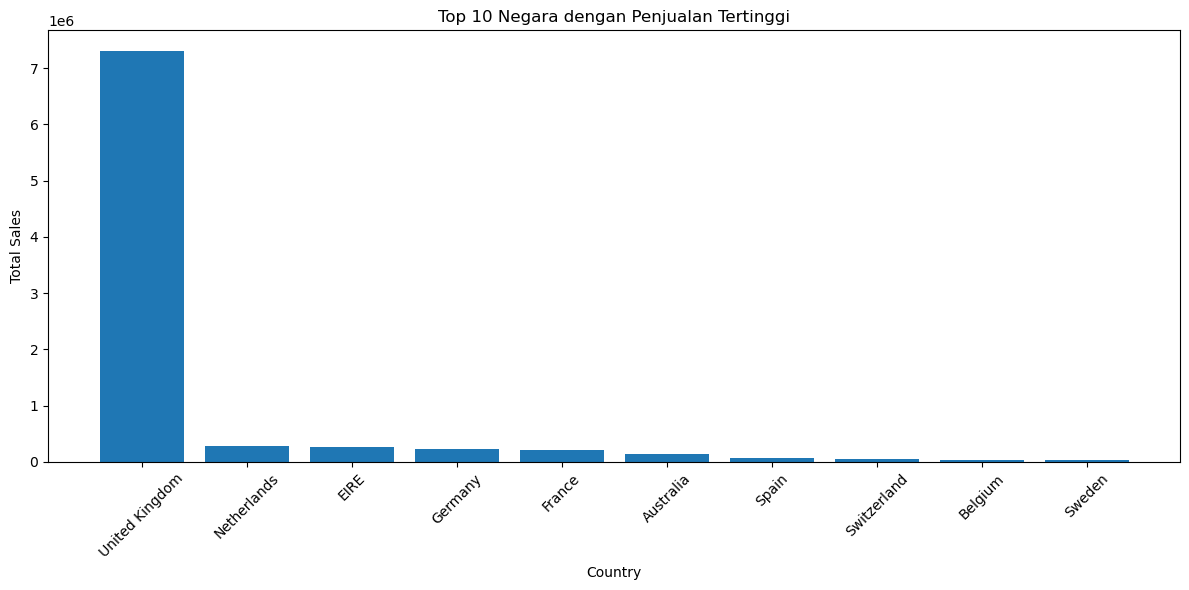

In [40]:
# Visualisasi

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(pdf["Country"], pdf["TotalSales"])

plt.xticks(rotation=45)

plt.title("Top 10 Negara dengan Penjualan Tertinggi")

plt.xlabel("Country")

plt.ylabel("Total Sales")

plt.tight_layout()

plt.show()

In [43]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [42]:
# Anomaly Detection

from sklearn.ensemble import IsolationForest

anomaly_df = postgres_df.select(
    "Quantity",
    "UnitPrice",
    "TotalPrice"
).toPandas()

model = IsolationForest(
    contamination=0.02,
    random_state=42
)

model.fit(anomaly_df)

anomaly_df["Anomaly"] = model.predict(anomaly_df)

anomaly_df.head()

,Quantity,UnitPrice,TotalPrice,Anomaly
0,10,1.65,16.5,1
1,6,2.95,17.7,1
2,48,1.25,60.0,1
3,4,5.95,23.8,1
4,4,1.25,5.0,1


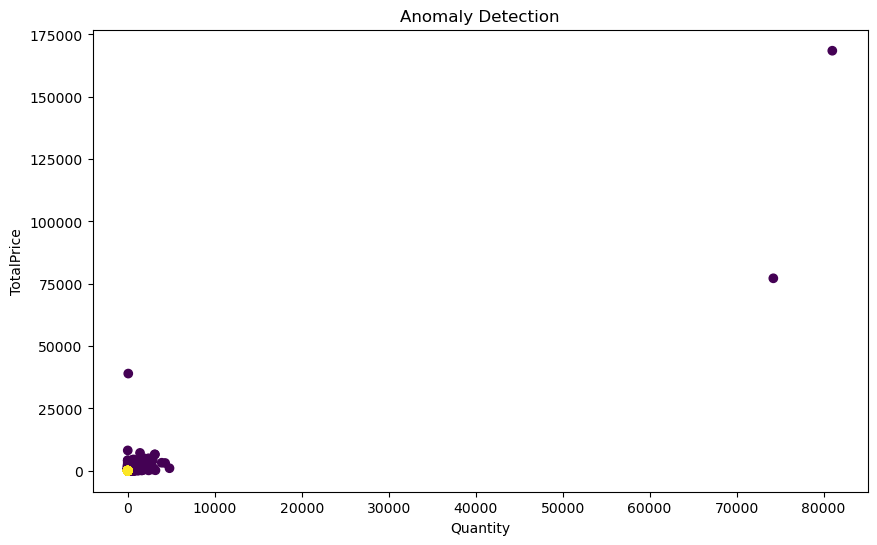

In [46]:
# Visualisasi Anomaly

plt.figure(figsize=(10,6))

plt.scatter(
    anomaly_df["Quantity"],
    anomaly_df["TotalPrice"],
    c=anomaly_df["Anomaly"]
)

plt.xlabel("Quantity")
plt.ylabel("TotalPrice")

plt.title("Anomaly Detection")

plt.show()

In [ ]:
# Stop Spark

spark.stop()

print("SPARK STOPPED")